# Model Performance in Unusual vs Normal Years — Cherry & Fruit Trees

**Question**: do phenology models perform worse in climatologically unusual years?

**Design**:
- Year classification: network-level z-score across all PEP725 fruit tree species (European data).
- Datasets: GMU Cherry (Japan/Switzerland/South Korea) + PEP725 fruit trees (Apple, Pear, Peach, Cherry, Plum).
- Per species: train on 70% of normal years; evaluate on held-out normal years
  and all unusual years — all three groups are fully out-of-sample.
- Models: Mean (baseline), Utah+GDD, ChillingDays+GDD, RandomForest, LSTM, Hybrid.
- Note: GMU Cherry Japan and South Korea are Asian datasets — their year classification
  is based on the European PEP725 network and may not fully capture local climate anomalies.

## Config

In [14]:
YEAR_MIN       = 1986
YEAR_MAX       = 2024

# Anomaly detection (based on PEP725 European fruit tree network)
MIN_CLIM_YEARS = 5     # minimum site-years to compute a reliable climatology
NET_Z_THRESH          = 0.5   # |mean_z| > this → unusual year
NORMAL_HOLDOUT_FRAC   = 0.3   # fraction of normal years held out for OOS evaluation

# Species to include — each is loaded and evaluated independently
# Format: display_name → (dataset_registry_key, obs_key)
SPECIES_DATASETS = {
    'Cherry JP':  ('GMU_Cherry_Japan_Y',     'gmu_0'),
    'Cherry CH':  ('GMU_Cherry_Switzerland', 'gmu_1'),
    'Cherry KR':  ('GMU_Cherry_South_Korea', 'gmu_2'),
    'Apple':      ('PEP725_Apple',   'BBCH_60'),
    'Pear':       ('PEP725_Pear',    'BBCH_60'),
    'Peach':      ('PEP725_Peach',   'BBCH_60'),
    'Cherry EU':  ('PEP725_Cherry',  'BBCH_60'),
    'Plum':       ('PEP725_Plum',    'BBCH_60'),
}

# Set True to run only Apple — fast check before full run
TEST_MODE = False

# Sample sufficiency thresholds
MIN_TRAIN_PB = 50    # min training samples for process-based / RF
MIN_TRAIN_DL = 300   # min training samples for neural models (LSTM, Hybrid)
MIN_TEST     = 20    # min test samples to include a species in evaluation

# Process-based model optimisation budget
OPT_MAX_TIME  = 60.0   # seconds per phase (hard cap)
OPT_MAX_STEPS = 400    # NLopt evaluations per phase

# Neural model training
DL_KW = dict(
    batch_size               = 512,
    num_epochs               = 1000,
    optimizer                = 'adam',
    optimizer_kwargs         = dict(lr=1e-3, weight_decay=1e-4),
    scheduler_step_size      = 100,
    scheduler_decay          = 0.9,
    early_stopping           = True,
    early_stopping_patience  = 10,
    early_stopping_min_delta = 1e-3,
    early_stopping_rerun     = True,
    val_period               = 10,
)

## 1. Classify years as unusual / normal

Network-level weighted z-score across all fruit tree species (all species,
regardless of whether they are later used for model fitting).

In [15]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

OBS_KEY_PEP = 'BBCH_60'  # obs key used only for year classification

from pysephone.data.pep725.source import PEP725Source
from pysephone.dataset.observations import Observations
from pysephone.dataset.preprocessing.pep725 import get_pep725_dataframes
from pysephone.constants import KEY_OBS_TYPE, KEY_OBSERVATIONS, KEY_SPECIES_ID

_SRC = PEP725Source.KEY

FRUIT_TREE_SPECIES = [
    (_SRC, 220), (_SRC, 227), (_SRC, 202), (_SRC, 782),
    (_SRC, 107), (_SRC, 222), (_SRC, 205), (_SRC, 225), (_SRC, 123),
]

raw_data = PEP725Source().get_data({})
dfs_raw  = get_pep725_dataframes(
    raw_data,
    filter_on_species=FRUIT_TREE_SPECIES,
    filter_on_observation_types=[OBS_KEY_PEP],
    filter_on_years=list(range(YEAR_MIN, YEAR_MAX + 1)),
    remove_outliers=False,
    datetime_observations=True,
)
obs_raw    = Observations(dfs_raw['data'], dfs_raw['locations'],
                          species_names=dfs_raw.get('species_names'))
id_to_name = {sid: name for (src, sid), name in obs_raw.species_names.items()}

df_raw = obs_raw._df_y.xs(OBS_KEY_PEP, level=KEY_OBS_TYPE).copy()
df_raw['doy'] = df_raw[KEY_OBSERVATIONS].dt.dayofyear
df_raw = df_raw.reset_index()
df_raw = df_raw.merge(obs_raw._df_y_loc.reset_index(), on=['src', 'loc_id'], how='left')
df_raw['species_name'] = df_raw[KEY_SPECIES_ID].map(id_to_name)

clim = (
    df_raw.groupby(['species_name', 'loc_id'])['doy']
          .agg(clim_mean='mean', clim_std='std', n_clim='count')
          .reset_index()
)
clim.loc[clim['n_clim'] < MIN_CLIM_YEARS, ['clim_mean', 'clim_std']] = np.nan
df_raw = df_raw.merge(clim, on=['species_name', 'loc_id'], how='left')
df_raw['anom_z'] = (df_raw['doy'] - df_raw['clim_mean']) / df_raw['clim_std']

yr_sp_z = (
    df_raw[df_raw['anom_z'].notna()]
          .groupby(['year', 'species_name'])['anom_z']
          .agg(mean_z='mean', n='count')
          .reset_index()
)
network_z = (
    yr_sp_z.groupby('year')
           .apply(lambda g: np.average(g['mean_z'], weights=g['n']),
                  include_groups=False)
           .rename('network_z')
)

year_type = {}
for yr, z in network_z.items():
    if   z < -NET_Z_THRESH: year_type[int(yr)] = 'early'
    elif z >  NET_Z_THRESH: year_type[int(yr)] = 'late'
    else:                   year_type[int(yr)] = 'normal'

unusual_early = sorted(y for y, t in year_type.items() if t == 'early')
unusual_late  = sorted(y for y, t in year_type.items() if t == 'late')
normal_years  = sorted(y for y, t in year_type.items() if t == 'normal')

print(f'Normal years  ({len(normal_years)}):         {normal_years}')
print(f'Unusual early ({len(unusual_early)}): {unusual_early}')
print(f'Unusual late  ({len(unusual_late)}):  {unusual_late}')

Checking for missing PEP725 data: 100%|██████████| 174/174 [00:00<00:00, 45063.84it/s]


Normal years  (19):         [1988, 1991, 1992, 1993, 1994, 1995, 1997, 1999, 2000, 2001, 2003, 2004, 2005, 2008, 2009, 2010, 2012, 2015, 2016]
Unusual early (7): [1989, 1990, 1998, 2002, 2007, 2011, 2014]
Unusual late  (5):  [1986, 1987, 1996, 2006, 2013]


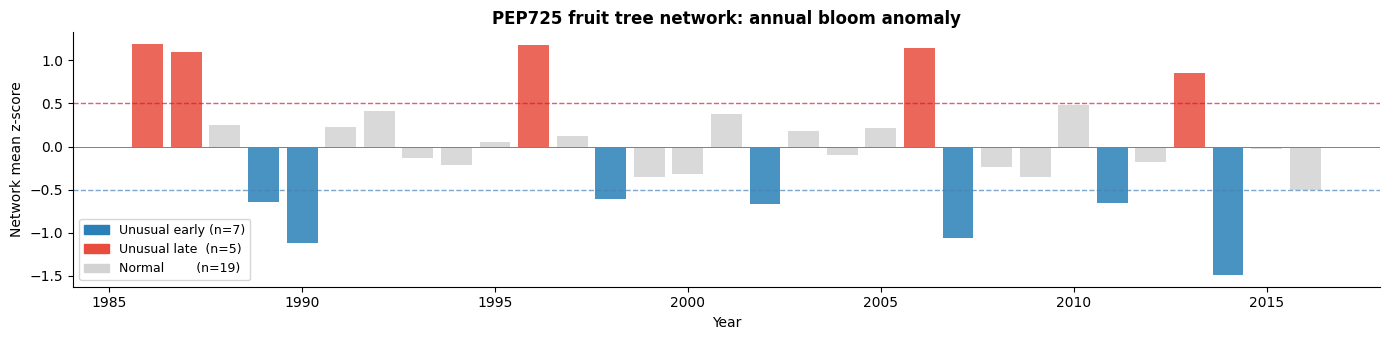

In [16]:
fig, ax = plt.subplots(figsize=(14, 3.5))
colors = [{'early': '#2980b9', 'late': '#e74c3c', 'normal': 'lightgrey'}[year_type.get(int(yr), 'normal')]
          for yr in network_z.index]
ax.bar(network_z.index, network_z.values, color=colors, width=0.8, alpha=0.85)
ax.axhline( NET_Z_THRESH, color='crimson',   lw=1, ls='--', alpha=0.7)
ax.axhline(-NET_Z_THRESH, color='steelblue', lw=1, ls='--', alpha=0.7)
ax.axhline(0, color='grey', lw=0.7)
ax.set_xlabel('Year'); ax.set_ylabel('Network mean z-score')
ax.set_title('PEP725 fruit tree network: annual bloom anomaly', fontweight='bold')
patches = [
    mpatches.Patch(color='#2980b9', label=f'Unusual early (n={len(unusual_early)})'),
    mpatches.Patch(color='#e74c3c', label=f'Unusual late  (n={len(unusual_late)})'),
    mpatches.Patch(color='lightgrey', label=f'Normal        (n={len(normal_years)})'),
]
ax.legend(handles=patches, fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

## 2. Load per-species datasets

Each species is loaded separately and split:
- **Train**: all normal years (used to fit models)
- **Test**: all unusual years (out-of-sample evaluation)

A random 30 % of normal years (seed 42) are held out and combined with the
unusual years to form the test set.  All three year-type groups — normal,
early, late — are evaluated fully out-of-sample.

In [17]:
from pysephone.dataset.dataset import Dataset
from pysephone.dataset.util.calendar import Calendar
from pysephone.dataset.util.openmeteo import OpenMeteoFeatures

cal      = Calendar(default_start='10-01', default_length=365)
features = OpenMeteoFeatures(calendar=cal, data_keys=['temperature_2m_mean'])


def make_splits(ds):
    """
    Train  = (1 - NORMAL_HOLDOUT_FRAC) of normal years.
    Test   = holdout normal years  +  all unusual years.
    All three year-type groups (normal/early/late) can then be evaluated OOS.
    """
    normal  = sorted(y for y in ds.years if year_type.get(y) == 'normal')
    unusual = sorted(y for y in ds.years if year_type.get(y) in ('early', 'late'))
    rng     = np.random.default_rng(42)
    n_ho    = max(1, round(len(normal) * NORMAL_HOLDOUT_FRAC))
    holdout = sorted(rng.choice(normal, n_ho, replace=False).tolist())
    train   = [y for y in normal if y not in set(holdout)]
    ds_trn  = ds.select_years(train)
    ds_tst  = ds.select_years(holdout + unusual)
    return ds_trn, ds_tst


datasets_to_run = (
    {'Apple': ('PEP725_Apple', 'BBCH_60')} if TEST_MODE
    else SPECIES_DATASETS
)

species_datasets    = {}   # sp_name -> (ds_trn, ds_tst)
species_target_fn   = {}   # sp_name -> target_fn

for sp_name, (ds_key, obs_key) in datasets_to_run.items():
    ds = Dataset.load(ds_key, calendar=cal, feature_providers=[features])
    # Download any missing OpenMeteo data for this dataset
    features.download(ds.observations, verbose=True)
    species_datasets[sp_name]  = make_splits(ds)
    species_target_fn[sp_name] = (lambda ok: lambda s: s['observations'][ok])(obs_key)

# ── Sample sufficiency check ─────────────────────────────────────────────────
print(f'{"Species":<14} {"Train":>7} {"Tst-norm":>9} {"Tst-unus":>9}  {"PB":>5}  {"DL":>5}  Note')
print('-' * 72)

species_ok_pb = {}
species_ok_dl = {}

for sp_name, (ds_trn, ds_tst) in species_datasets.items():
    n_trn  = len(ds_trn)
    n_norm = sum(1 for y in ds_tst.years if year_type.get(y) == 'normal')
    n_unus = sum(1 for y in ds_tst.years if year_type.get(y) in ('early', 'late'))
    n_tst  = len(ds_tst)
    ok_pb  = n_trn >= MIN_TRAIN_PB and n_tst >= MIN_TEST
    ok_dl  = n_trn >= MIN_TRAIN_DL and n_tst >= MIN_TEST
    notes  = []
    if not ok_pb:
        notes.append(f'SKIP all (train={n_trn} or test={n_tst})')
    elif not ok_dl:
        notes.append(f'skip DL (train={n_trn}<{MIN_TRAIN_DL})')
    print(f'{sp_name:<14} {n_trn:>7} {n_norm:>9} {n_unus:>9}  {str(ok_pb):>5}  {str(ok_dl):>5}  {"; ".join(notes)}')
    if ok_pb:
        species_ok_pb[sp_name] = (ds_trn, ds_tst)
    if ok_dl:
        species_ok_dl[sp_name] = (ds_trn, ds_tst)

print()
print(f'PB/RF : {list(species_ok_pb)}')
print(f'DL    : {list(species_ok_dl)}')

Checking for missing meteo data: 100%|██████████| 4010/4010 [00:03<00:00, 1194.16it/s, step=daily, data_key=temperature_2m_mean, location_id=(pep725, 8074), year=2016, n_missing=0/4010] 


Species          Train  Tst-norm  Tst-unus     PB     DL  Note
------------------------------------------------------------------------
Cherry JP          763         6        12   True   True  
Cherry CH          391         6        12   True   True  
Cherry KR          217         4        10   True  False  skip DL (train=217<300)
Apple             3229         5        12   True   True  
Pear              1479         5        12   True   True  
Peach               77         3         9   True  False  skip DL (train=77<300)
Cherry EU         3257         6        12   True   True  
Plum              1011         6        12   True   True  

PB/RF : ['Cherry JP', 'Cherry CH', 'Cherry KR', 'Apple', 'Pear', 'Peach', 'Cherry EU', 'Plum']
DL    : ['Cherry JP', 'Cherry CH', 'Apple', 'Pear', 'Cherry EU', 'Plum']


## 3. Fit models per species

In [18]:
import torch
from pysephone.models.cf            import UtahGDDModel, ChillingDaysGDDModel
from pysephone.models.random_forest import RandomForestModel
from pysephone.models.lstm          import LSTMModel
from pysephone.models.hybrid        import HybridModel

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}\n')

OPT_KW = dict(opt_max_time=OPT_MAX_TIME, opt_max_steps=OPT_MAX_STEPS)


class MeanModel:
    """Baseline: predicts the mean bloom DOY from the training set."""
    def __init__(self):
        self._mean_doy = None

    @classmethod
    def fit(cls, target_fn, dataset, **kwargs):
        m = cls()
        doys = []
        for s in dataset.iter_items():
            dt = np.datetime64(target_fn(s), 'D')
            yr_start = dt.astype('datetime64[Y]').astype('datetime64[D]')
            doys.append(float((dt - yr_start) / np.timedelta64(1, 'D')) + 1.0)
        m._mean_doy = int(round(np.mean(doys)))
        return m, {'mean_doy': m._mean_doy}

    def predict(self, sample):
        yr   = int(sample['year'])
        date = np.datetime64(f'{yr}-01-01', 'D') + np.timedelta64(self._mean_doy - 1, 'D')
        return date, {}


PB_SPECS = [
    ('Utah+GDD',         UtahGDDModel,        dict(threshold_c=50.0, threshold_f=200.0, t_base=4.0,
                                                    **OPT_KW)),
    ('ChillingDays+GDD', ChillingDaysGDDModel, dict(threshold_c=50.0, threshold_f=200.0, t_chill=7.2,
                                                    t_base=4.0, params_opt=['th_c', 'th_f', 't_base'],
                                                    **OPT_KW)),
]

fitted = {}

for sp_name, (ds_trn, _) in species_ok_pb.items():
    target_fn = species_target_fn[sp_name]
    print(f'── {sp_name} ──────────────────────────────────────────')
    fitted[sp_name] = {}

    m, info = MeanModel.fit(target_fn=target_fn, dataset=ds_trn)
    fitted[sp_name]['Mean'] = m
    print(f'  Mean done  (mean_doy={info["mean_doy"]})')

    for name, cls_, kwargs in PB_SPECS:
        print(f'  {name} ...', end=' ', flush=True)
        model, _ = cls_.fit(target_fn=target_fn, dataset=ds_trn, model_kwargs=kwargs)
        fitted[sp_name][name] = model
        print(f'done  {model.params}')

    print(f'  RandomForest ...', end=' ', flush=True)
    rf, _ = RandomForestModel.fit(target_fn=target_fn, dataset=ds_trn,
                                  model_kwargs=dict(data_keys=['temperature_2m_mean']))
    fitted[sp_name]['RandomForest'] = rf
    print('done')

    if sp_name in species_ok_dl:
        print(f'  LSTM ...')
        lstm, _ = LSTMModel.fit(
            target_fn=target_fn, dataset=ds_trn,
            model_kwargs=dict(data_keys=['temperature_2m_mean'],
                              hidden_size=64, num_layers=2),
            **DL_KW, device=device, verbose=False,
        )
        fitted[sp_name]['LSTM'] = lstm
        print(f'  LSTM done')

        print(f'  Hybrid ...')
        hybrid, _ = HybridModel.fit(
            target_fn=target_fn, dataset=ds_trn,
            model_kwargs=dict(data_keys=['temperature_2m_mean']),
            **DL_KW, device=device, verbose=False,
        )
        fitted[sp_name]['Hybrid'] = hybrid
        print(f'  Hybrid done')
    else:
        print(f'  LSTM / Hybrid skipped (insufficient training data)')

# ── Max observed training DOY per species (for CF no-bloom correction) ───────
max_train_doy = {}
for sp_name, (ds_trn, _) in species_ok_pb.items():
    tfn  = species_target_fn[sp_name]
    doys = []
    for s in ds_trn.iter_items():
        dt = np.datetime64(tfn(s), 'D')
        yr_start = dt.astype('datetime64[Y]').astype('datetime64[D]')
        doys.append(float((dt - yr_start) / np.timedelta64(1, 'D')) + 1.0)
    max_train_doy[sp_name] = int(max(doys))
print('Max training DOY per species:', max_train_doy)

Device: cuda

── Cherry JP ──────────────────────────────────────────
  Mean done  (mean_doy=101)
  Utah+GDD ... done  {'th_c': 1.2633069171543065, 'th_f': 440.4823331380344, 't_base': 2.5976910166891}
  ChillingDays+GDD ... done  {'th_c': 0.43848958389454373, 'th_f': 807.3400961955093, 't_chill': 7.2, 't_base': 0.6952129861147507}
  RandomForest ... done
  LSTM ...
  LSTM done
  Hybrid ...
  Hybrid done
── Cherry CH ──────────────────────────────────────────
  Mean done  (mean_doy=115)
  Utah+GDD ... done  {'th_c': 58.49391596181257, 'th_f': 118.71343885609247, 't_base': 5.590256344564257}
  ChillingDays+GDD ... done  {'th_c': 44.02522330190063, 'th_f': 111.1538745595221, 't_chill': 7.2, 't_base': 5.85007690920564}
  RandomForest ... done
  LSTM ...
  LSTM done
  Hybrid ...
  Hybrid done
── Cherry KR ──────────────────────────────────────────
  Mean done  (mean_doy=100)
  Utah+GDD ... done  {'th_c': 36.625514403292186, 'th_f': 111.11111111111116, 't_base': 5.932784636488341}
  Chillin

## 4. Evaluate per species and year type

Normal-year holdout, early years, and late years are **all out-of-sample** —
a clean like-for-like comparison.  The training set is used only to fit the
models; no training-set metrics are reported.


In [19]:
from pysephone.evaluation.regression import SingleTargetRegression, _datetime64_to_doy

MODEL_ORDER = ['Mean', 'Utah+GDD', 'ChillingDays+GDD', 'RandomForest', 'LSTM', 'Hybrid']
YT_COLORS   = {'normal': '#95a5a6', 'early': '#2980b9', 'late': '#e74c3c'}
YT_ORDER    = ['normal', 'early', 'late']


def metrics_by_year_type(df_pred, label):
    df = df_pred.copy()
    df['year_type'] = df['year'].map(lambda y: year_type.get(int(y), 'unknown'))
    rows = []
    for yt in ('normal', 'early', 'late'):
        sub = df[df['year_type'] == yt]
        if sub.empty:
            continue
        errs = sub['error'].values
        rows.append({'year_type': yt, 'split': label, 'n_years': sub['year'].nunique(),
                     'n_samples': len(sub), 'MAE': float(np.mean(np.abs(errs))),
                     'RMSE': float(np.sqrt(np.mean(errs**2))), 'Bias': float(np.mean(errs))})
    return pd.DataFrame(rows).set_index('year_type')


def collect_with_req_met(model, dataset, target_fn):
    """Like _collect_predictions but also records req_met for CF models."""
    rows = []
    for sample in dataset.iter_items():
        obs_dt  = target_fn(sample)
        pred_dt, info = model.predict(sample)
        obs_doy  = _datetime64_to_doy(np.datetime64(obs_dt,  'D'))
        pred_doy = _datetime64_to_doy(np.datetime64(pred_dt, 'D'))
        rows.append({'year': int(sample['year']), 'predicted_doy': pred_doy,
                     'observed_doy': obs_doy, 'error': pred_doy - obs_doy,
                     'req_met': info.get('req_met', True)})
    return pd.DataFrame(rows)


eval_results  = {}
slice_metrics = {}
req_met_data  = {}   # {sp: {model: df with req_met column}} — CF models only

CF_MODELS = {'Utah+GDD', 'ChillingDays+GDD'}

for sp_name, (ds_trn, ds_tst) in species_ok_pb.items():
    eval_results[sp_name]  = {}
    slice_metrics[sp_name] = {}
    req_met_data[sp_name]  = {}

    for name, model in fitted[sp_name].items():
        target_fn = species_target_fn[sp_name]
        result = SingleTargetRegression.run(
            model=model, dataset_train=ds_trn, dataset_test=ds_tst,
            target_fn=target_fn,
            run_name=f'{name.lower().replace("+","_").replace(" ","_")}_{sp_name.lower()}',
        )
        eval_results[sp_name][name]  = result
        slice_metrics[sp_name][name] = metrics_by_year_type(result.df_test, 'test')

        if name in CF_MODELS:
            req_met_data[sp_name][name] = {
                'test': collect_with_req_met(model, ds_tst, species_target_fn[sp_name]),
            }

print('Evaluation complete.')

Evaluation complete.


In [20]:
rows = []
for sp_name in species_ok_pb:
    for model_name in MODEL_ORDER:
        if model_name not in slice_metrics[sp_name]:
            continue
        sm = slice_metrics[sp_name][model_name]
        for yt, row in sm.iterrows():
            rows.append({'Species': sp_name, 'Model': model_name,
                         'Year type': yt, 'N years': int(row['n_years']),
                         'N samples': int(row['n_samples']), 'MAE': round(row['MAE'], 1),
                         'RMSE': round(row['RMSE'], 1), 'Bias': round(row['Bias'], 1)})
df_summary = pd.DataFrame(rows).set_index(['Species', 'Model', 'Year type'])
display(df_summary)

N years  N samples   MAE  RMSE  Bias
Species   Model    Year type                                      
Cherry JP Mean     normal           6        337   7.5   9.1   2.4
                   early            7        397   9.0  10.3   5.2
                   late             5        300   8.9  11.5  -0.3
          Utah+GDD normal           6        337  15.4  41.4  10.1
                   early            7        397  16.5  37.8   3.6
...                               ...        ...   ...   ...   ...
Plum      LSTM     early            7        878   7.4   9.7   3.9
                   late             5        734   3.7   5.3  -0.9
          Hybrid   normal           6        481   6.0   8.2   1.0
                   early            7        878  11.2  13.7  10.0
                   late             5        734   6.4   7.6  -5.5

[132 rows x 5 columns]

## 5. Statistical test: are unusual-year errors larger?

Mann-Whitney U test (one-sided, H₁: unusual > normal) on absolute prediction
errors, pooled across all qualified species.  All three groups are fully
**out-of-sample** — normal years come from the held-out fraction, early/late
years are the unusual test set.  No in-sample confound.


In [21]:
from scipy.stats import mannwhitneyu


def pool_errors_model(year_type_label, model_name, outer_test_dfs=None):
    """Collect |errors| for a given year type and model, pooled across species.
    outer_test_dfs: optional {sp_name: {model_name: df}} override.
    """
    errs = []
    for sp_name in species_ok_pb:
        if outer_test_dfs is not None:
            df = outer_test_dfs[sp_name].get(model_name)
        else:
            result = eval_results[sp_name].get(model_name)
            df = result.df_test if result is not None else None
        if df is None or df.empty:
            continue
        df = df.copy()
        df['_yt'] = df['year'].map(lambda y: year_type.get(int(y), 'unknown'))
        sub = df[df['_yt'] == year_type_label]['error'].values
        errs.extend(np.abs(sub).tolist())
    return np.array(errs)


def mwu(a, b, label_a, label_b):
    if len(a) == 0 or len(b) == 0:
        print(f'    H1: |err({label_a})| > |err({label_b})|   insufficient data')
        return
    stat, p = mannwhitneyu(a, b, alternative='greater')
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f'    H1: |err({label_a})| > |err({label_b})|   p={p:.2e}  {sig}')


def print_model_stats(model_name, outer_test_dfs=None):
    errs_n = pool_errors_model('normal',  model_name, outer_test_dfs)
    errs_e = pool_errors_model('early',   model_name, outer_test_dfs)
    errs_l = pool_errors_model('late',    model_name, outer_test_dfs)
    errs_u = np.concatenate([errs_e, errs_l])
    if len(errs_n) == 0:
        return
    print(f'   Normal  : n={len(errs_n):5d}  mean={errs_n.mean():.2f} d  median={np.median(errs_n):.2f} d')
    print(f'   Early   : n={len(errs_e):5d}  mean={errs_e.mean():.2f} d  median={np.median(errs_e):.2f} d')
    print(f'   Late    : n={len(errs_l):5d}  mean={errs_l.mean():.2f} d  median={np.median(errs_l):.2f} d')
    print(f'   Unusual : n={len(errs_u):5d}  mean={errs_u.mean():.2f} d  median={np.median(errs_u):.2f} d')
    mwu(errs_u, errs_n, 'unusual', 'normal')
    mwu(errs_e, errs_n, 'early',   'normal')
    mwu(errs_l, errs_n, 'late',    'normal')


print('|error| summary and Mann-Whitney U (one-sided) — per model, pooled across species:\n')
for model_name in MODEL_ORDER:
    print(f'── {model_name}')
    print_model_stats(model_name)
    print()

|error| summary and Mann-Whitney U (one-sided) — per model, pooled across species:

── Mean
   Normal  : n= 4577  mean=6.71 d  median=5.00 d
   Early   : n= 5781  mean=10.85 d  median=10.00 d
   Late    : n= 4107  mean=9.22 d  median=8.00 d
   Unusual : n= 9888  mean=10.17 d  median=9.00 d
    H1: |err(unusual)| > |err(normal)|   p=5.28e-212  ***
    H1: |err(early)| > |err(normal)|   p=1.81e-219  ***
    H1: |err(late)| > |err(normal)|   p=1.72e-100  ***

── Utah+GDD
   Normal  : n= 4577  mean=9.05 d  median=6.00 d
   Early   : n= 5781  mean=10.01 d  median=7.00 d
   Late    : n= 4107  mean=7.43 d  median=4.00 d
   Unusual : n= 9888  mean=8.93 d  median=5.00 d
    H1: |err(unusual)| > |err(normal)|   p=1.00e+00  ns
    H1: |err(early)| > |err(normal)|   p=9.70e-04  ***
    H1: |err(late)| > |err(normal)|   p=1.00e+00  ns

── ChillingDays+GDD
   Normal  : n= 4577  mean=9.89 d  median=7.00 d
   Early   : n= 5781  mean=11.45 d  median=8.00 d
   Late    : n= 4107  mean=6.89 d  median=4.00

## 6. MAE by model and year type — per species

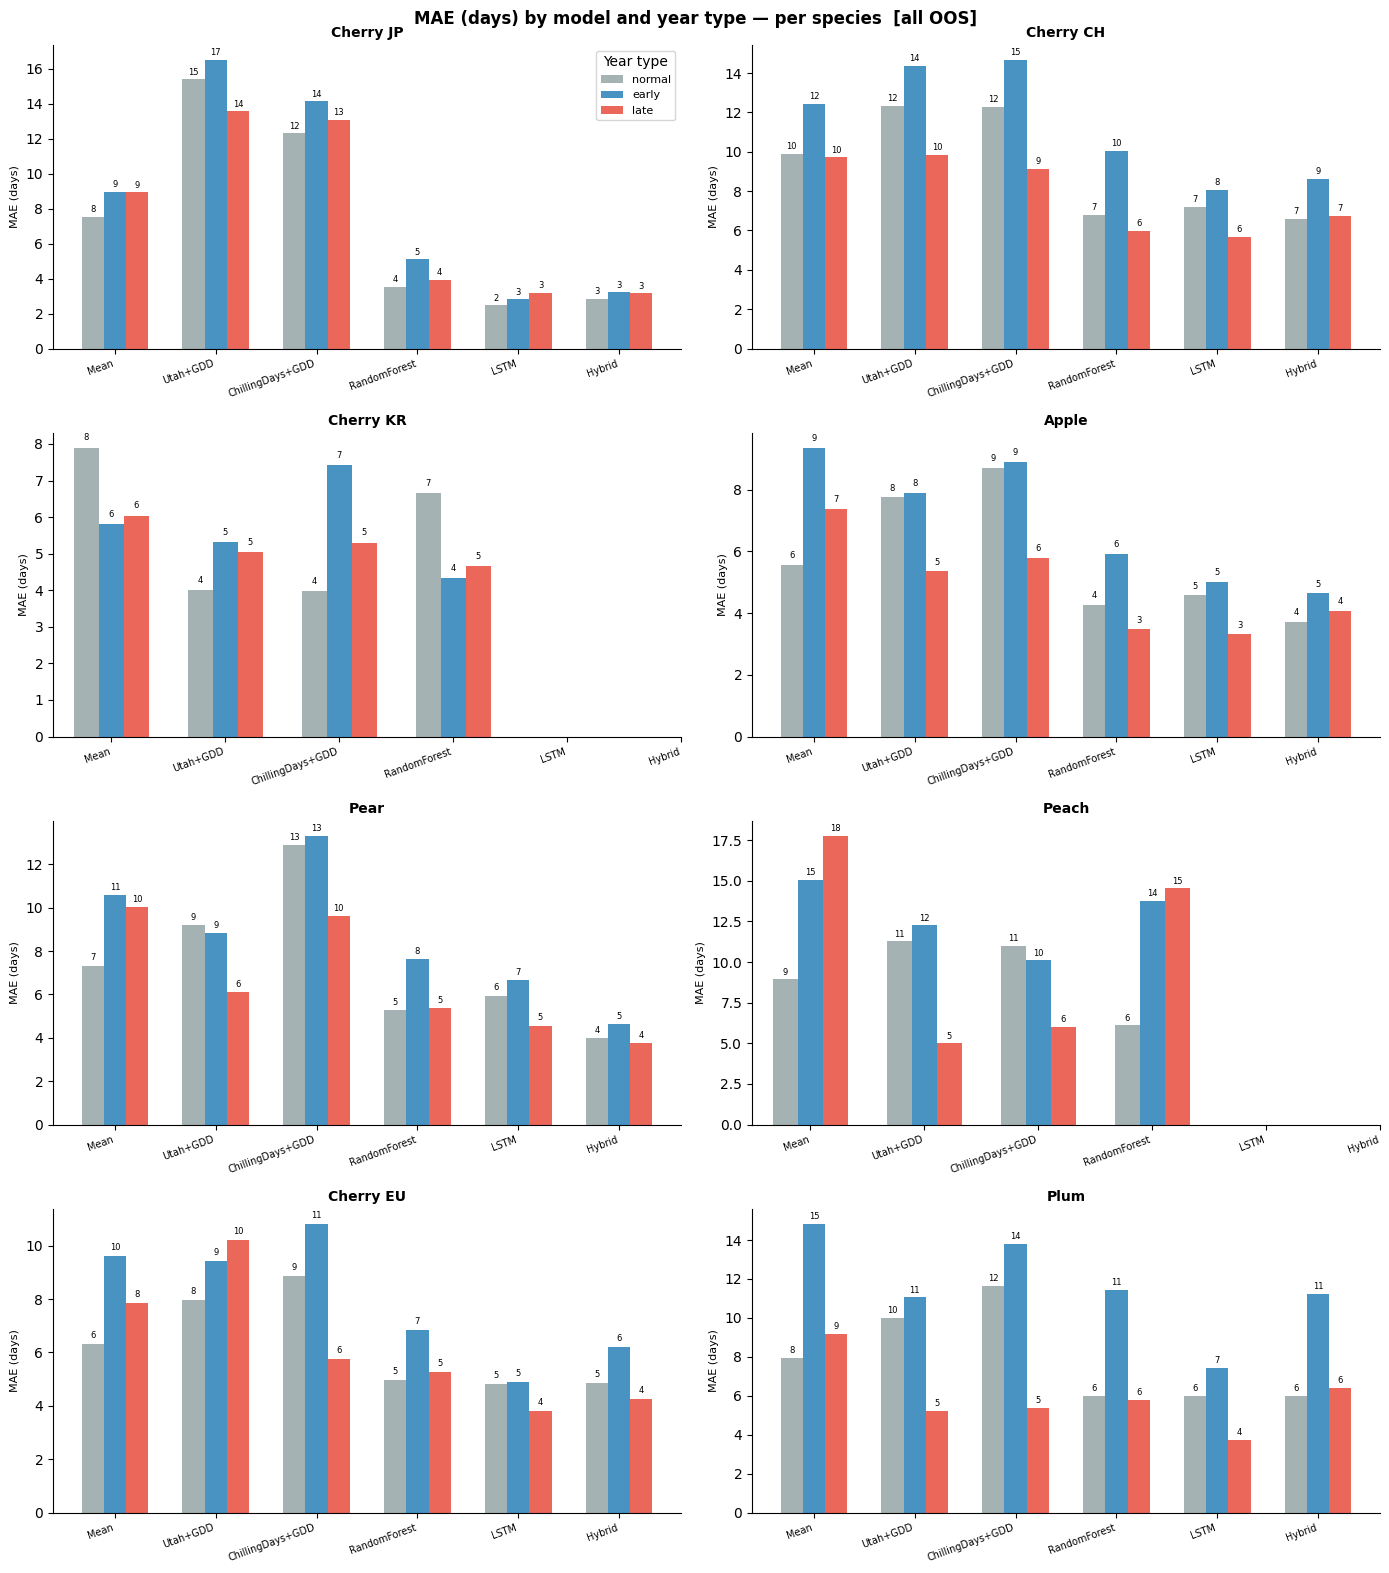

In [22]:
n_sp   = len(species_ok_pb)
n_cols = 2
n_rows = (n_sp + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows), sharey=False)
axes = axes.flatten()
fig.suptitle('MAE (days) by model and year type — per species  [all OOS]',
             fontsize=12, fontweight='bold')

x      = np.arange(len(MODEL_ORDER))
width  = 0.22
offset = -(len(YT_ORDER) - 1) / 2 * width

for ax, sp_name in zip(axes, species_ok_pb):
    for i, yt in enumerate(YT_ORDER):
        maes = []
        for m in MODEL_ORDER:
            sm = slice_metrics[sp_name].get(m)
            maes.append(sm.loc[yt, 'MAE'] if (sm is not None and yt in sm.index) else np.nan)
        bars = ax.bar(x + offset + i * width, maes, width,
                      label=yt, color=YT_COLORS[yt], alpha=0.85)
        for bar, val in zip(bars, maes):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
                        f'{val:.0f}', ha='center', va='bottom', fontsize=6)
    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_ORDER, fontsize=7, rotation=20, ha='right')
    ax.set_ylabel('MAE (days)', fontsize=8)
    ax.set_title(sp_name, fontweight='bold', fontsize=10)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    if ax is axes[0]:
        ax.legend(title='Year type', fontsize=8)

for ax in axes[n_sp:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

## 7. Cross-species mean MAE

Mean MAE  Std  N sp
Model            Year type                     
Mean             normal          7.7  1.3     8
                 early          10.8  2.9     8
                 late            9.6  3.3     8
Utah+GDD         normal          9.7  3.2     8
                 early          10.7  3.4     8
                 late            7.5  3.0     8
ChillingDays+GDD normal         10.2  2.8     8
                 early          11.6  2.5     8
                 late            7.5  2.6     8
RandomForest     normal          5.4  1.1     8
                 early           8.1  3.1     8
                 late            6.1  3.3     8
LSTM             normal          5.2  1.5     6
                 early           5.8  1.8     6
                 late            4.0  0.8     6
Hybrid           normal          4.7  1.3     6
                 early           6.4  2.7     6
                 late            4.7  1.3     6

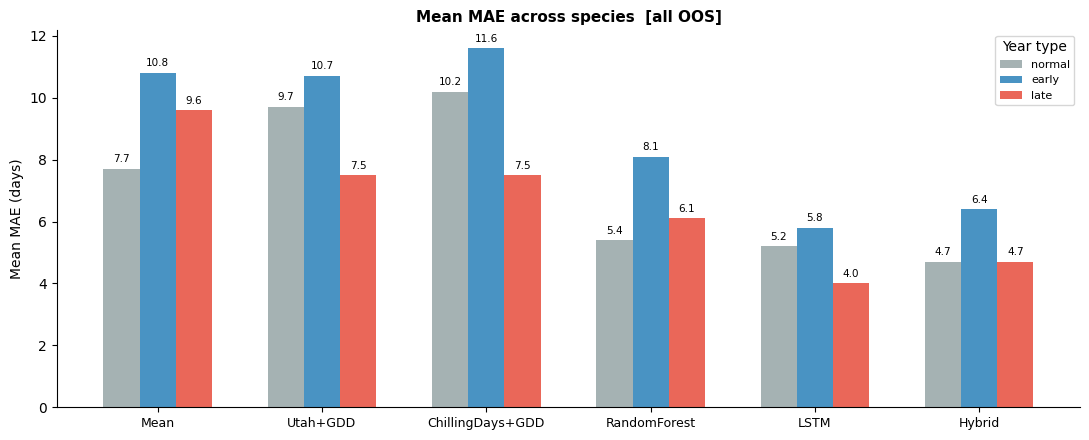

In [23]:
agg_rows = []
for model_name in MODEL_ORDER:
    for yt in YT_ORDER:
        vals = [slice_metrics[sp].get(model_name).loc[yt, 'MAE']
                for sp in species_ok_pb
                if model_name in slice_metrics[sp] and yt in slice_metrics[sp][model_name].index]
        if vals:
            agg_rows.append({'Model': model_name, 'Year type': yt,
                             'Mean MAE': round(np.mean(vals), 1),
                             'Std':      round(np.std(vals),  1),
                             'N sp':     len(vals)})

df_agg = pd.DataFrame(agg_rows).set_index(['Model', 'Year type'])
display(df_agg)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.set_title('Mean MAE across species  [all OOS]',
             fontsize=11, fontweight='bold')
for i, yt in enumerate(YT_ORDER):
    maes = [df_agg.loc[(m, yt), 'Mean MAE'] if (m, yt) in df_agg.index else np.nan
            for m in MODEL_ORDER]
    bars = ax.bar(x + offset + i * width, maes, width,
                  label=yt, color=YT_COLORS[yt], alpha=0.85)
    for bar, val in zip(bars, maes):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
                    f'{val:.1f}', ha='center', va='bottom', fontsize=7.5)
ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER, fontsize=9)
ax.set_ylabel('Mean MAE (days)')
ax.legend(title='Year type', fontsize=8)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

## 8. Scatter plots — predicted vs observed (pooled across species)

Test-set predictions (unusual years) only, coloured by year type.

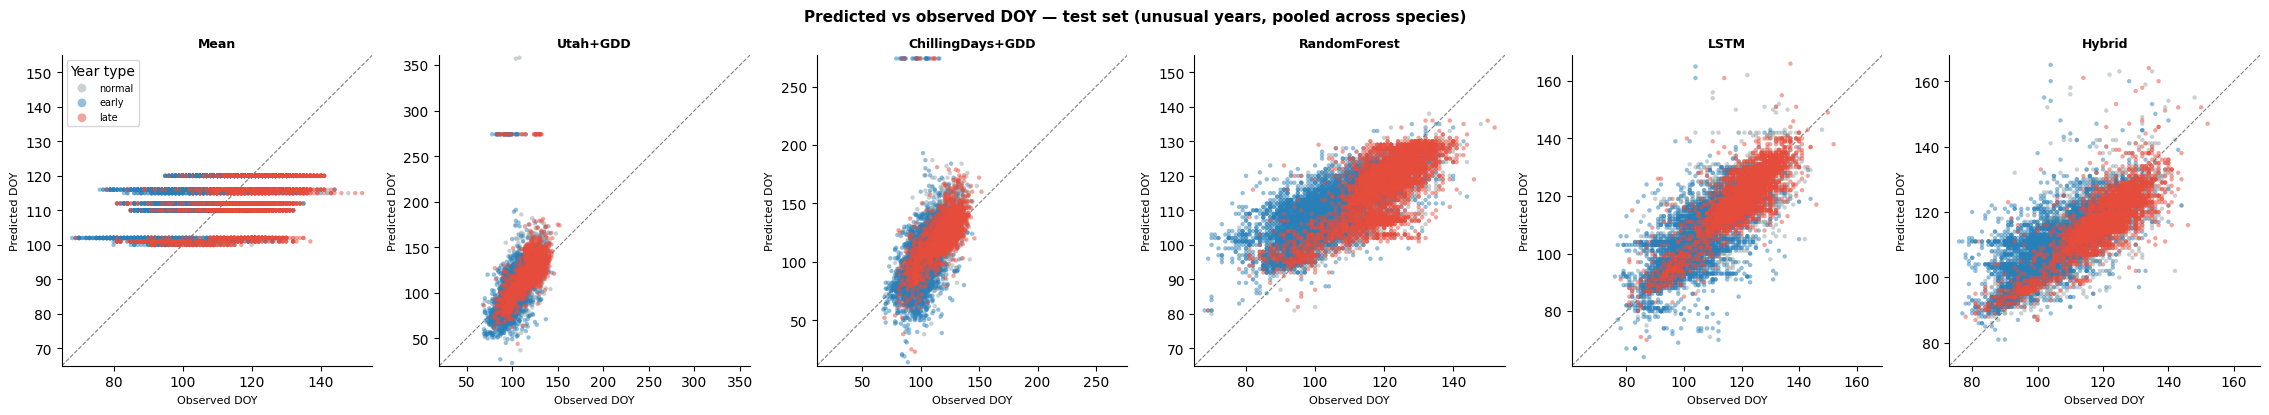

In [24]:
n_models  = len(MODEL_ORDER)
fig, axes = plt.subplots(1, n_models, figsize=(3.8 * n_models, 4))
fig.suptitle('Predicted vs observed DOY — test set (unusual years, pooled across species)',
             fontweight='bold', fontsize=11)

for ax, name in zip(axes, MODEL_ORDER):
    frames = []
    for sp_name in species_ok_pb:
        result = eval_results[sp_name].get(name)
        if result is None or result.df_test.empty:
            continue
        df = result.df_test.copy()
        df['year_type'] = df['year'].map(lambda y: year_type.get(int(y), 'unknown'))
        frames.append(df)
    if not frames:
        ax.set_visible(False); continue
    df_all = pd.concat(frames, ignore_index=True)

    for yt in YT_ORDER:
        sub = df_all[df_all['year_type'] == yt]
        if sub.empty: continue
        ax.scatter(sub['observed_doy'], sub['predicted_doy'],
                   c=YT_COLORS[yt], s=10, alpha=0.5, edgecolors='none',
                   label=yt, zorder={'normal': 1, 'early': 3, 'late': 3}[yt])

    lo = df_all[['observed_doy','predicted_doy']].min().min() - 3
    hi = df_all[['observed_doy','predicted_doy']].max().max() + 3
    ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8, alpha=0.5)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel('Observed DOY', fontsize=8)
    ax.set_ylabel('Predicted DOY', fontsize=8)
    ax.set_title(name, fontsize=9, fontweight='bold')
    ax.set_aspect('equal')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    if ax is axes[0]:
        ax.legend(fontsize=7, title='Year type', markerscale=2)

plt.tight_layout(); plt.show()

## 9. Why do process-based models struggle in unusual years?

Process-based (CF) models calibrate fixed thresholds for chilling and forcing
accumulation on the *training distribution* (normal years).  In unusual years
the temperature sequence departs from that distribution in two systematic ways:

**Unusually early years (warm winter / spring)**
The warm winter may deliver fewer chill hours than usual.  If the chilling
requirement `th_c` is not met, the model's forcing phase never starts — or
starts very late — and the model predicts bloom at the end of the season
(*"no bloom" prediction*, see Section 10).  Even when chilling is met, the
warm spring compresses the forcing accumulation window in a way the model
wasn't trained on, producing systematic bias.

**Unusually late years (cold spring)**
Chill accumulates abundantly, but forcing accumulates slowly.  The model
may still predict the right order-of-magnitude date, but the calibrated
`th_f` tends to be met earlier in temperature-space than the actual event.

**Why ML models are less affected**
RandomForest, LSTM, and the Hybrid model encode the *full temperature
sequence* as a feature rather than just its running sum.  They can, in
principle, detect that the sequence is unusual and adjust.  However, since
they are also trained only on normal years, they are extrapolating OOD — the
difference is that they degrade *smoothly* (biased predictions) rather than
hitting a hard structural failure (no-bloom).

## 10. Error distribution (test set, pooled across species)

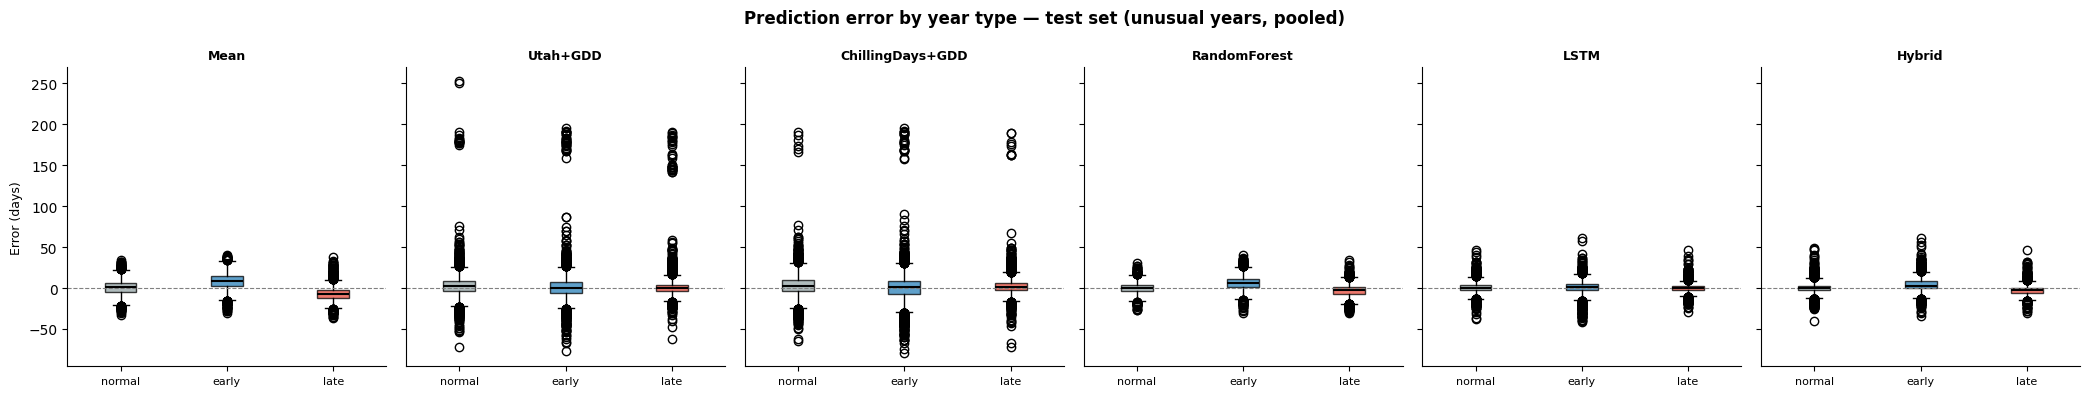

In [25]:
fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(3.5 * len(MODEL_ORDER), 4), sharey=True)
fig.suptitle('Prediction error by year type — test set (unusual years, pooled)',
             fontweight='bold')

for ax, name in zip(axes, MODEL_ORDER):
    frames = []
    for sp_name in species_ok_pb:
        result = eval_results[sp_name].get(name)
        if result is None or result.df_test.empty: continue
        df = result.df_test.copy()
        df['year_type'] = df['year'].map(lambda y: year_type.get(int(y), 'unknown'))
        frames.append(df)
    if not frames:
        ax.set_visible(False); continue
    df_all = pd.concat(frames, ignore_index=True)

    data = [df_all[df_all['year_type'] == yt]['error'].values for yt in YT_ORDER]
    bp   = ax.boxplot(data, patch_artist=True, medianprops=dict(color='black', lw=1.5))
    for patch, yt in zip(bp['boxes'], YT_ORDER):
        patch.set_facecolor(YT_COLORS[yt]); patch.set_alpha(0.75)
    ax.axhline(0, color='grey', lw=0.8, ls='--')
    ax.set_xticks(range(1, len(YT_ORDER) + 1))
    ax.set_xticklabels(YT_ORDER, fontsize=8)
    ax.set_title(name, fontsize=9, fontweight='bold')
    if ax is axes[0]:
        ax.set_ylabel('Error (days)', fontsize=9)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout(); plt.show()

## 11. No-bloom analysis (CF models only)

CF models occasionally fail to predict bloom within the season window because
the chilling or forcing threshold is never reached.  In that case the model
returns the last day of the season as the prediction — a catastrophic error.
This section quantifies how often this occurs and recomputes metrics after
excluding those predictions.

In [26]:
print('No-bloom rate (req_met == False) per model / species / split:\n')
print(f'  {"Species":<14} {"Model":<20} {"Split":>6}  {"N":>5}  {"No-bloom":>8}  {"Rate":>6}')
print('  ' + '-' * 62)

for sp_name in species_ok_pb:
    for cf_name in ('Utah+GDD', 'ChillingDays+GDD'):
        if cf_name not in req_met_data.get(sp_name, {}):
            continue
        for split in ('test',):
            df = req_met_data[sp_name][cf_name][split]
            n_total   = len(df)
            n_nobloom = int((~df['req_met']).sum())
            rate      = n_nobloom / n_total if n_total else 0.0
            print(f'  {sp_name:<14} {cf_name:<20} {split:>6}  {n_total:>5}  {n_nobloom:>8}  {rate:>5.1%}')

# ── Filtered metrics (excluding no-bloom predictions) ────────────────────────
print('\nFiltered MAE (no-bloom predictions removed):\n')

rows_filt = []
for sp_name in species_ok_pb:
    for cf_name in ('Utah+GDD', 'ChillingDays+GDD'):
        if cf_name not in req_met_data.get(sp_name, {}):
            continue
        for split in ('test',):
            df = req_met_data[sp_name][cf_name][split].copy()
            df['year_type'] = df['year'].map(lambda y: year_type.get(int(y), 'unknown'))
            df_filt = df[df['req_met']]
            for yt in ('normal', 'early', 'late'):
                sub_all  = df[df['year_type'] == yt]
                sub_filt = df_filt[df_filt['year_type'] == yt]
                if sub_all.empty:
                    continue
                mae_all  = np.mean(np.abs(sub_all['error']))
                mae_filt = np.mean(np.abs(sub_filt['error'])) if not sub_filt.empty else np.nan
                rows_filt.append({'Species': sp_name, 'Model': cf_name, 'Split': split,
                                  'Year type': yt, 'N all': len(sub_all),
                                  'N filtered': len(sub_filt),
                                  'MAE (all)': round(mae_all, 1),
                                  'MAE (filtered)': round(mae_filt, 1) if not np.isnan(mae_filt) else np.nan,
                                  'Delta MAE': round(mae_all - mae_filt, 1) if not np.isnan(mae_filt) else np.nan})

df_filt_summary = pd.DataFrame(rows_filt).set_index(['Species', 'Model', 'Split', 'Year type'])
display(df_filt_summary)

# ── Corrected CF evaluation: no-bloom → max observed training DOY ─────────────
print()
print('=' * 70)
print('Corrected CF: no-bloom predictions replaced by max observed train DOY')
print('=' * 70)
print()

# Build corrected test dataframes for all models
corrected_test_dfs = {}   # {sp_name: {model_name: df_with_year_and_error}}
for sp_name in species_ok_pb:
    corrected_test_dfs[sp_name] = {}
    max_doy = max_train_doy[sp_name]

    for model_name in MODEL_ORDER:
        if model_name not in fitted[sp_name]:
            continue
        if model_name in CF_MODELS and model_name in req_met_data.get(sp_name, {}):
            df = req_met_data[sp_name][model_name]['test'].copy()
            nobloom = ~df['req_met']
            if nobloom.any():
                df.loc[nobloom, 'predicted_doy'] = max_doy
                df.loc[nobloom, 'error'] = max_doy - df.loc[nobloom, 'observed_doy']
            corrected_test_dfs[sp_name][model_name] = df
        else:
            result = eval_results[sp_name].get(model_name)
            if result is not None:
                corrected_test_dfs[sp_name][model_name] = result.df_test.copy()

# ── Comparison table: original vs corrected MAE (CF models only) ────────────
print('Original vs corrected MAE for CF models (all OOS, pooled across species):\n')
print(f'  {"Model":<22} {"Year type":<10} {"MAE orig":>9}  {"MAE corr":>9}  {"Delta":>7}')
print('  ' + '-' * 62)

for model_name in CF_MODELS:
    for yt in YT_ORDER:
        errs_orig = pool_errors_model(yt, model_name)
        errs_corr = pool_errors_model(yt, model_name, corrected_test_dfs)
        if len(errs_orig) == 0:
            continue
        delta = errs_corr.mean() - errs_orig.mean()
        print(f'  {model_name:<22} {yt:<10} {errs_orig.mean():>9.2f}  {errs_corr.mean():>9.2f}  {delta:>+7.2f}')

# ── Mann-Whitney on corrected data ────────────────────────────────────────────
print()
print('Mann-Whitney U (one-sided, corrected) — per model, pooled across species:\n')
for model_name in CF_MODELS:
    print(f'── {model_name}  [corrected]')
    print_model_stats(model_name, corrected_test_dfs)
    print()

No-bloom rate (req_met == False) per model / species / split:

  Species        Model                 Split      N  No-bloom    Rate
  --------------------------------------------------------------
  Cherry JP      Utah+GDD               test   1034        36   3.5%
  Cherry JP      ChillingDays+GDD       test   1034         6   0.6%
  Cherry CH      Utah+GDD               test    542         0   0.0%
  Cherry CH      ChillingDays+GDD       test    542         0   0.0%
  Cherry KR      Utah+GDD               test    235         0   0.0%
  Cherry KR      ChillingDays+GDD       test    235         1   0.4%
  Apple          Utah+GDD               test   3532         6   0.2%
  Apple          ChillingDays+GDD       test   3532        11   0.3%
  Pear           Utah+GDD               test   1805        12   0.7%
  Pear           ChillingDays+GDD       test   1805         9   0.5%
  Peach          Utah+GDD               test    916         1   0.1%
  Peach          ChillingDays+GDD       tes

N all  N filtered  MAE (all)  \
Species   Model            Split Year type                                 
Cherry JP Utah+GDD         test  normal       337         324       15.4   
                                 early        397         381       16.5   
                                 late         300         293       13.6   
          ChillingDays+GDD test  normal       337         336       12.3   
                                 early        397         393       14.1   
                                 late         300         299       13.1   
Cherry CH Utah+GDD         test  normal       182         182       12.3   
                                 early        212         212       14.4   
                                 late         148         148        9.8   
          ChillingDays+GDD test  normal       182         182       12.3   
                                 early        212         212       14.7   
                                 late         148         148        9.1   
Cherry KR Utah+GDD         test  normal        48          48        4.0   
                                 early         92          92        5.3   
                                 late          95          95        5.0   
          ChillingDays+GDD test  normal        48          48        4.0   
                                 early         92          91        7.4   
                                 late          95          95        5.3   
Apple     Utah+GDD         test  normal      1289        1289        7.8   
                                 early       1389        1384        7.9   
                                 late         854         853        5.4   
          ChillingDays+GDD test  normal      1289        1287        8.7   
                                 early       1389        1383        8.9   
                                 late         854         851        5.8   
Pear      Utah+GDD         test  normal       397         396        9.2   
                                 early        848         842        8.8   
                                 late         560         555        6.1   
          ChillingDays+GDD test  normal       397         396       12.9   
                                 early        848         842       13.3   
                                 late         560         558        9.6   
Peach     Utah+GDD         test  normal       192         192       11.3   
                                 early        383         382       12.3   
                                 late         341         341        5.0   
          ChillingDays+GDD test  normal       192         191       11.0   
                                 early        383         383       10.1   
                                 late         341         341        6.0   
Cherry EU Utah+GDD         test  normal      1651        1651        8.0   
                                 early       1582        1579        9.4   
                                 late        1075        1055       10.2   
          ChillingDays+GDD test  normal      1651        1650        8.9   
                                 early       1582        1577       10.8   
                                 late        1075        1072        5.7   
Plum      Utah+GDD         test  normal       481         481       10.0   
                                 early        878         876       11.0   
                                 late         734         734        5.2   
          ChillingDays+GDD test  normal       481         481       11.6   
                                 early        878         875       13.8   
                                 late         734         734        5.4   

                                            MAE (filtered)  Delta MAE  
Species   Model            Split Year type                             
Cherry JP Utah+GDD         test  normal                8.8        6.6  
                           


Corrected CF: no-bloom predictions replaced by max observed train DOY

Original vs corrected MAE for CF models (all OOS, pooled across species):

  Model                  Year type   MAE orig   MAE corr    Delta
  --------------------------------------------------------------
  ChillingDays+GDD       normal          9.89       9.71    -0.18
  ChillingDays+GDD       early          11.45      10.85    -0.60
  ChillingDays+GDD       late            6.89       6.59    -0.30
  Utah+GDD               normal          9.05       8.63    -0.42
  Utah+GDD               early          10.01       9.22    -0.79
  Utah+GDD               late            7.43       6.30    -1.13

Mann-Whitney U (one-sided, corrected) — per model, pooled across species:

── ChillingDays+GDD  [corrected]
   Normal  : n= 4577  mean=9.71 d  median=7.00 d
   Early   : n= 5781  mean=10.85 d  median=8.00 d
   Late    : n= 4107  mean=6.59 d  median=4.00 d
   Unusual : n= 9888  mean=9.08 d  median=6.00 d
    H1: |err(unusual

## 12. Corrected CF evaluation — cross-species MAE comparison

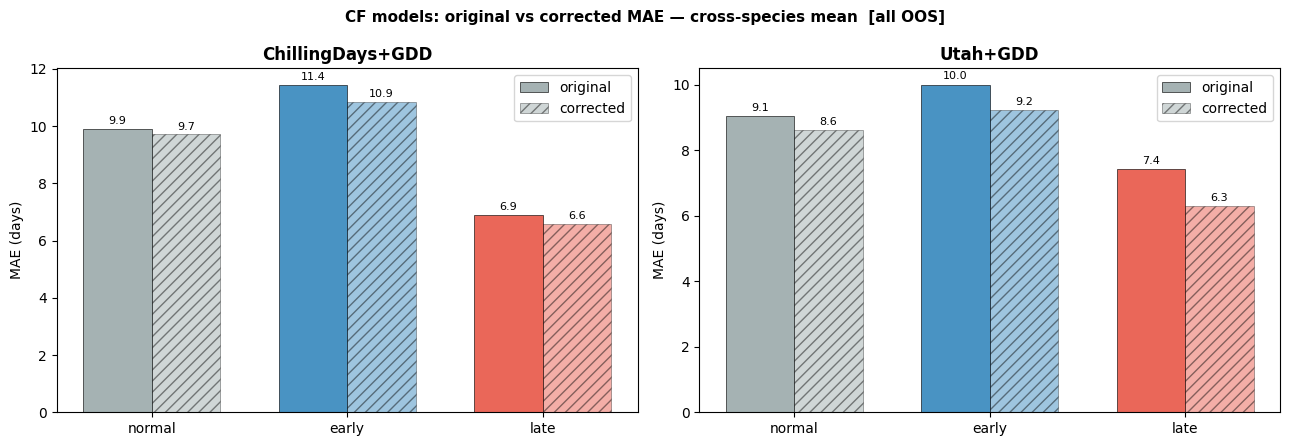

In [27]:
cf_models_to_plot = [m for m in CF_MODELS if any(m in corrected_test_dfs.get(sp, {}) for sp in species_ok_pb)]
yt_labels = YT_ORDER

fig, axes = plt.subplots(1, len(cf_models_to_plot), figsize=(6.5 * len(cf_models_to_plot), 4.5), sharey=False)
if len(cf_models_to_plot) == 1:
    axes = [axes]
fig.suptitle('CF models: original vs corrected MAE — cross-species mean  [all OOS]',
             fontweight='bold', fontsize=11)

x       = np.arange(len(yt_labels))
width   = 0.35
hatches = ('', '///')

for ax, model_name in zip(axes, cf_models_to_plot):
    for i, (variant, outer_dfs) in enumerate([('original', None), ('corrected', corrected_test_dfs)]):
        maes = []
        for yt in yt_labels:
            errs = pool_errors_model(yt, model_name, outer_dfs)
            maes.append(errs.mean() if len(errs) else np.nan)
        bars = ax.bar(x + (i - 0.5) * width, maes, width,
                      color=[YT_COLORS[yt] for yt in yt_labels],
                      alpha=0.85 if variant == 'original' else 0.45,
                      hatch=hatches[i], edgecolor='black', linewidth=0.5,
                      label=variant)
        for bar, val in zip(bars, maes):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                        f'{val:.1f}', ha='center', va='bottom', fontsize=8)

    ax.set_title(model_name, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(yt_labels)
    ax.set_ylabel('MAE (days)')
    ax.legend()

plt.tight_layout()
plt.show()